# Model Training & Evaluation

Notebook para entrenar y evaluar modelos de clasificación para la predicción de Churn.

**Modelos:** Logistic Regression, Random Forest, XGBoost, Gradient Boosting

**Métricas:** Recall, F1-Macro, AUC-ROC

**Validación:** Stratified K-Fold (5 folds)

**Optimización:** GridSearchCV

**Tracking:** MLflow

## 1. Configuración e Imports

In [11]:
import pandas as pd
import numpy as np
import os
import warnings
import mlflow
import mlflow.sklearn
import joblib
import xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✓ Imports completados")

✓ Imports completados


In [12]:
from pathlib import Path
import mlflow

repo = Path("/Users/nataliabernalgutierrez/Churn-Prediction").resolve()
mlruns_dir = repo / "mlruns"
mlruns_dir.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"file://{mlruns_dir}")
print("Tracking URI:", mlflow.get_tracking_uri())

exp = mlflow.set_experiment("churn_prediction")
print("Experiment:", exp.name, exp.experiment_id)

Tracking URI: file:///Users/nataliabernalgutierrez/Churn-Prediction/mlruns
Experiment: churn_prediction 131122253193653250


## 2. Carga de Datos

In [13]:
test_folder = '../data/resampled/original'
X_test = pd.read_csv(f'{test_folder}/X_test.csv')
y_test = pd.read_csv(f'{test_folder}/y_test.csv')['Churn']

print(f"Test set: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
print(f"Distribución test:\n{y_test.value_counts()}")

Test set: 1407 muestras, 30 features
Distribución test:
Churn
0    1033
1     374
Name: count, dtype: int64


In [14]:
resampled_dir = '../data/resampled'
datasets = {}

for folder in sorted(os.listdir(resampled_dir)):
    if folder == 'original':
        continue
    path = os.path.join(resampled_dir, folder)
    if os.path.isdir(path) and 'X_train.csv' in os.listdir(path):
        X = pd.read_csv(f'{path}/X_train.csv')
        y = pd.read_csv(f'{path}/y_train.csv')['Churn']
        datasets[folder] = (X, y)
        print(f"✓ {folder}: {X.shape[0]} muestras, {X.shape[1]} features")

print(f"\nDatasets cargados: {list(datasets.keys())}")

✓ adasyn: 8292 muestras, 30 features
✓ random_over: 8260 muestras, 30 features
✓ random_under: 2990 muestras, 30 features
✓ smote: 8260 muestras, 30 features
✓ smote_enn: 4596 muestras, 30 features
✓ smote_tomek: 7506 muestras, 30 features

Datasets cargados: ['adasyn', 'random_over', 'random_under', 'smote', 'smote_enn', 'smote_tomek']


## 3. Definición de Modelos y Hiperparámetros

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'NaiveBayes': GaussianNB(),
    'SVM': SVC(random_state=42, probability=True),
    'XGBoost': xgboost.XGBClassifier(random_state=42, eval_metric='logloss'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

print(f"Modelos definidos: {list(models.keys())}")

Modelos definidos: ['LogisticRegression', 'RandomForest', 'NaiveBayes', 'SVM', 'XGBoost', 'GradientBoosting']


In [31]:
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'NaiveBayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

print("Hiperparámetros definidos para cada modelo")

Hiperparámetros definidos para cada modelo


## 4. Entrenamiento con GridSearchCV + MLflow

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

total = len(datasets) * len(models)
current = 0

for dataset_name, (X_train, y_train) in datasets.items():
    for model_name, model in models.items():
        current += 1
        print(f"\n{'='*60}")
        print(f"[{current}/{total}] Dataset: {dataset_name} | Modelo: {model_name}")
        print(f"{'='*60}")

        with mlflow.start_run(run_name=f"{dataset_name}_{model_name}"):
            mlflow.log_param("dataset", dataset_name)
            mlflow.log_param("model", model_name)
            mlflow.log_param("train_samples", X_train.shape[0])
            mlflow.log_param("features", X_train.shape[1])

            grid_search = GridSearchCV(
                model,
                param_grids[model_name],
                cv=cv,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=0
            )
            grid_search.fit(X_train, y_train)

            mlflow.log_params(grid_search.best_params_)

            best_model = grid_search.best_estimator_
            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)[:, 1]

            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')
            auc_roc = roc_auc_score(y_test, y_proba)

            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1_macro", f1)
            mlflow.log_metric("auc_roc", auc_roc)
            mlflow.log_metric("best_cv_score", grid_search.best_score_)

            artifact_name = f"{dataset_name}_{model_name}".replace(" ", "_")
            mlflow.sklearn.log_model(best_model, artifact_path=artifact_name)

            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Recall': recall,
                'F1-Macro': f1,
                'AUC-ROC': auc_roc,
                'Best_CV_F1_Macro': grid_search.best_score_,
                'Best_Params': str(grid_search.best_params_)
            })

            print(f"  ✓ Recall: {recall:.4f} | F1-Macro: {f1:.4f} | AUC-ROC: {auc_roc:.4f}")
            print(f"  ✓ Best CV F1-Macro: {grid_search.best_score_:.4f}")

print(f"\n{'='*60}")
print(f"✓ Entrenamiento completado: {len(results)} experimentos")
print(f"{'='*60}")


[1/36] Dataset: adasyn | Modelo: LogisticRegression


/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

  ✓ Recall: 0.6791 | F1: 0.6040 | AUC-ROC: 0.8171
  ✓ Best CV F1: 0.8292

[2/36] Dataset: adasyn | Modelo: RandomForest


2026/09/16 23:02:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 23:02:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/09/16 23:02:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ✓ Recall: 0.6417 | F1: 0.5948 | AUC-ROC: 0.8087
  ✓ Best CV F1: 0.8452

[3/36] Dataset: adasyn | Modelo: NaiveBayes


2026/09/16 23:02:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  ✓ Recall: 0.8048 | F1: 0.5828 | AUC-ROC: 0.7993
  ✓ Best CV F1: 0.8004

[4/36] Dataset: adasyn | Modelo: SVM


KeyboardInterrupt: 

## 5. Evaluación en Test Set

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Macro', ascending=False)

print("\n📊 Resultados ordenados por F1-Macro:")
print(results_df[['Dataset', 'Model', 'Recall', 'F1-Macro', 'AUC-ROC']].to_string(index=False))


📊 Resultados ordenados por F1-Score:
     Dataset              Model   Recall  F1-Score  AUC-ROC
   smote_enn   GradientBoosting 0.732620  0.625571 0.818501
   smote_enn       RandomForest 0.740642  0.624577 0.825262
random_under            XGBoost 0.810160  0.618999 0.836070
random_under   GradientBoosting 0.820856  0.617706 0.835876
random_under       RandomForest 0.828877  0.613254 0.838750
       smote LogisticRegression 0.663102  0.611591 0.825610
 random_over LogisticRegression 0.796791  0.611282 0.836202
   smote_enn LogisticRegression 0.729947  0.610738 0.831575
   smote_enn            XGBoost 0.716578  0.609784 0.824909
 smote_tomek LogisticRegression 0.657754  0.604423 0.828176
random_under LogisticRegression 0.794118  0.604273 0.834357
      adasyn LogisticRegression 0.679144  0.604043 0.817061
       smote       RandomForest 0.631016  0.598226 0.819583
       smote            XGBoost 0.633690  0.596226 0.819977
      adasyn       RandomForest 0.641711  0.594796 0.808734
 r

In [ ]:
best = results_df.iloc[0]
print(f"\n🏆 Mejor modelo: {best['Model']} con dataset {best['Dataset']}")
print(f"   Recall:    {best['Recall']:.4f}")
print(f"   F1-Macro:  {best['F1-Macro']:.4f}")
print(f"   AUC-ROC:   {best['AUC-ROC']:.4f}")


🏆 Mejor modelo: GradientBoosting con dataset smote_enn
   Recall:    0.7326
   F1-Score:  0.6256
   AUC-ROC:   0.8185


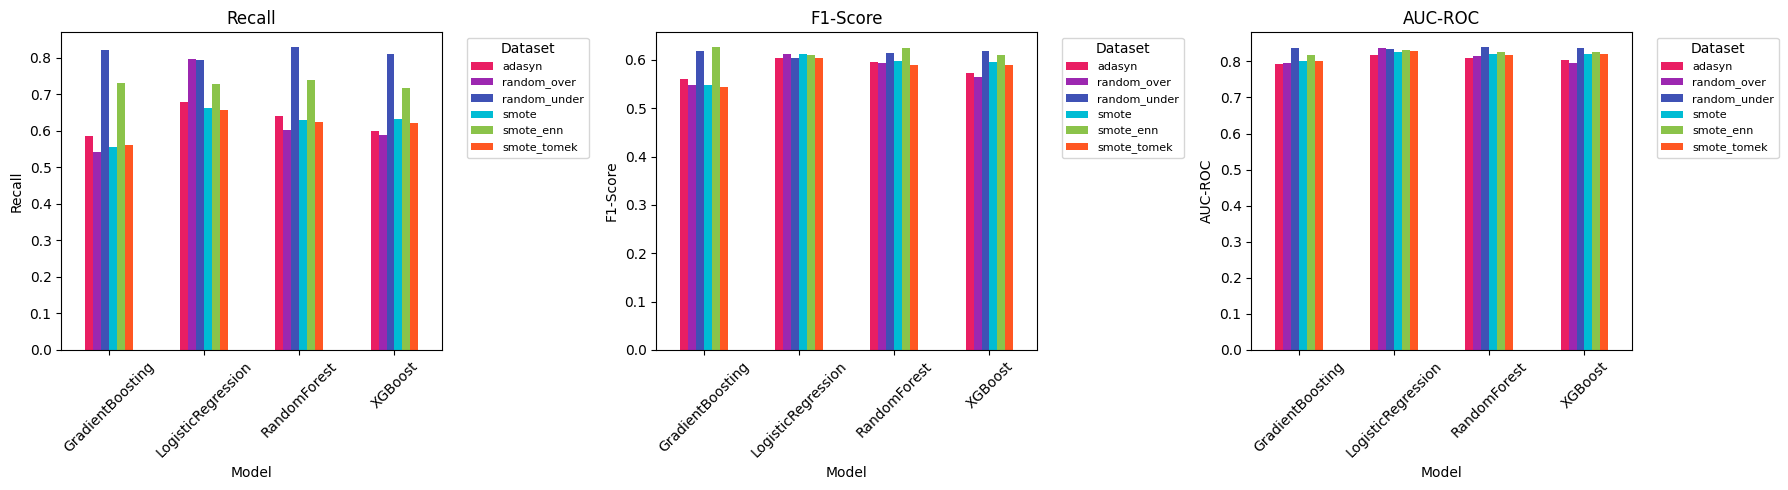

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Recall', 'F1-Macro', 'AUC-ROC']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for idx, metric in enumerate(metrics):
    pivot = results_df.pivot_table(index='Model', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=axes[idx], color=['#E91E63', '#9C27B0', '#3F51B5', '#00BCD4', '#8BC34A', '#FF5722'])
    axes[idx].set_title(metric)
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Optimización de Threshold

In [22]:
best_model_name = best['Model']
best_dataset_name = best['Dataset']
best_params_str = best['Best_Params']

import ast
best_params = ast.literal_eval(best_params_str)

X_train_best, y_train_best = datasets[best_dataset_name]

final_model = models[best_model_name].set_params(**best_params)
final_model.fit(X_train_best, y_train_best)

y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Modelo final: {best_model_name} (Dataset: {best_dataset_name})")
print(f"Parámetros: {best_params}")

Modelo final: GradientBoosting (Dataset: smote_enn)
Parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Macro': f1_score(y_test, y_pred_t, average='macro'),
        'Predictions_Pos': y_pred_t.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n📊 Métricas por Threshold:")
print(threshold_df.to_string(index=False))


📊 Métricas por Threshold:
 Threshold   Recall  F1-Score  Predictions_Pos
      0.10 0.780749  0.611518              581
      0.15 0.770053  0.616702              560
      0.20 0.759358  0.615385              549
      0.25 0.756684  0.619934              539
      0.30 0.751337  0.623751              527
      0.35 0.743316  0.621229              521
      0.40 0.743316  0.626126              514
      0.45 0.740642  0.625989              511
      0.50 0.732620  0.625571              502
      0.55 0.729947  0.626866              497
      0.60 0.721925  0.626450              488
      0.65 0.708556  0.618436              483
      0.70 0.697861  0.615566              474
      0.75 0.695187  0.614657              472
      0.80 0.684492  0.610979              464
      0.85 0.673797  0.606498              457


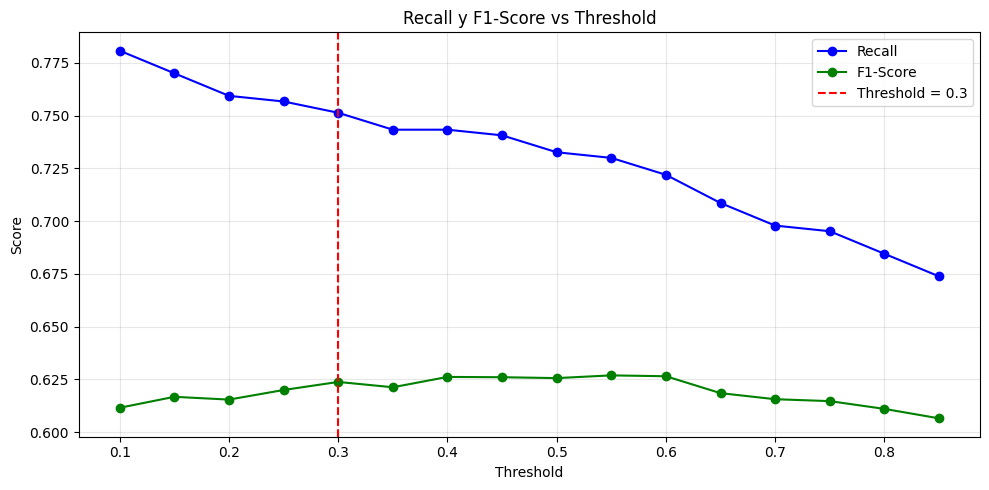

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(threshold_df['Threshold'], threshold_df['Recall'], 'b-o', label='Recall')
ax1.plot(threshold_df['Threshold'], threshold_df['F1-Macro'], 'g-o', label='F1-Macro')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.axvline(x=0.3, color='r', linestyle='--', label='Threshold = 0.3')
ax1.legend(loc='upper right')
ax1.set_title('Recall y F1-Macro vs Threshold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
THRESHOLD = 0.3
y_pred_final = (y_proba >= THRESHOLD).astype(int)

print(f"\n📊 Resultados con Threshold = {THRESHOLD}")
print(f"{'='*40}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Macro:  {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))
print(f"\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_final, digits=4))


📊 Resultados con Threshold = 0.3
Recall:    0.7513
F1-Score:  0.6238
AUC-ROC:   0.8185

Matriz de Confusión:
[[787 246]
 [ 93 281]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



## 7. Guardar Resultados

In [26]:
os.makedirs('../data/results', exist_ok=True)

results_df.to_csv('../data/results/model_training_results.csv', index=False)
print("✓ Resultados guardados en model_training_results.csv")

✓ Resultados guardados en model_training_results.csv


In [27]:
joblib.dump(final_model, f'../data/results/best_model_{best_model_name}.joblib')
print(f"✓ Mejor modelo guardado: best_model_{best_model_name}.joblib")

✓ Mejor modelo guardado: best_model_GradientBoosting.joblib


In [28]:
print(f"\n{'='*60}")
print(f"✓ PIPELINE COMPLETADO")
print(f"{'='*60}")
print(f"\nArchivos generados:")
print(f"  - ../data/results/model_training_results.csv")
print(f"  - ../data/results/best_model_{best_model_name}.joblib")
print(f"  - mlruns/ (MLflow experiments)")
print(f"\nPara ver MLflow UI ejecuta:")
print(f"  mlflow ui")


✓ PIPELINE COMPLETADO

Archivos generados:
  - ../data/results/model_training_results.csv
  - ../data/results/best_model_GradientBoosting.joblib
  - mlruns/ (MLflow experiments)

Para ver MLflow UI ejecuta:
  mlflow ui
